
# LLM数据处理核心技术：过滤与去重

## 1\. 数据过滤（Filtering）

### 1.1 算法概述

**目标**：给定一个庞大的原始数据集 $R$，和一个小型的高质量目标数据集 $T$，找到 $R$ 的一个子集 $T'$，使得 $T'$ 与 $T$ 相似。
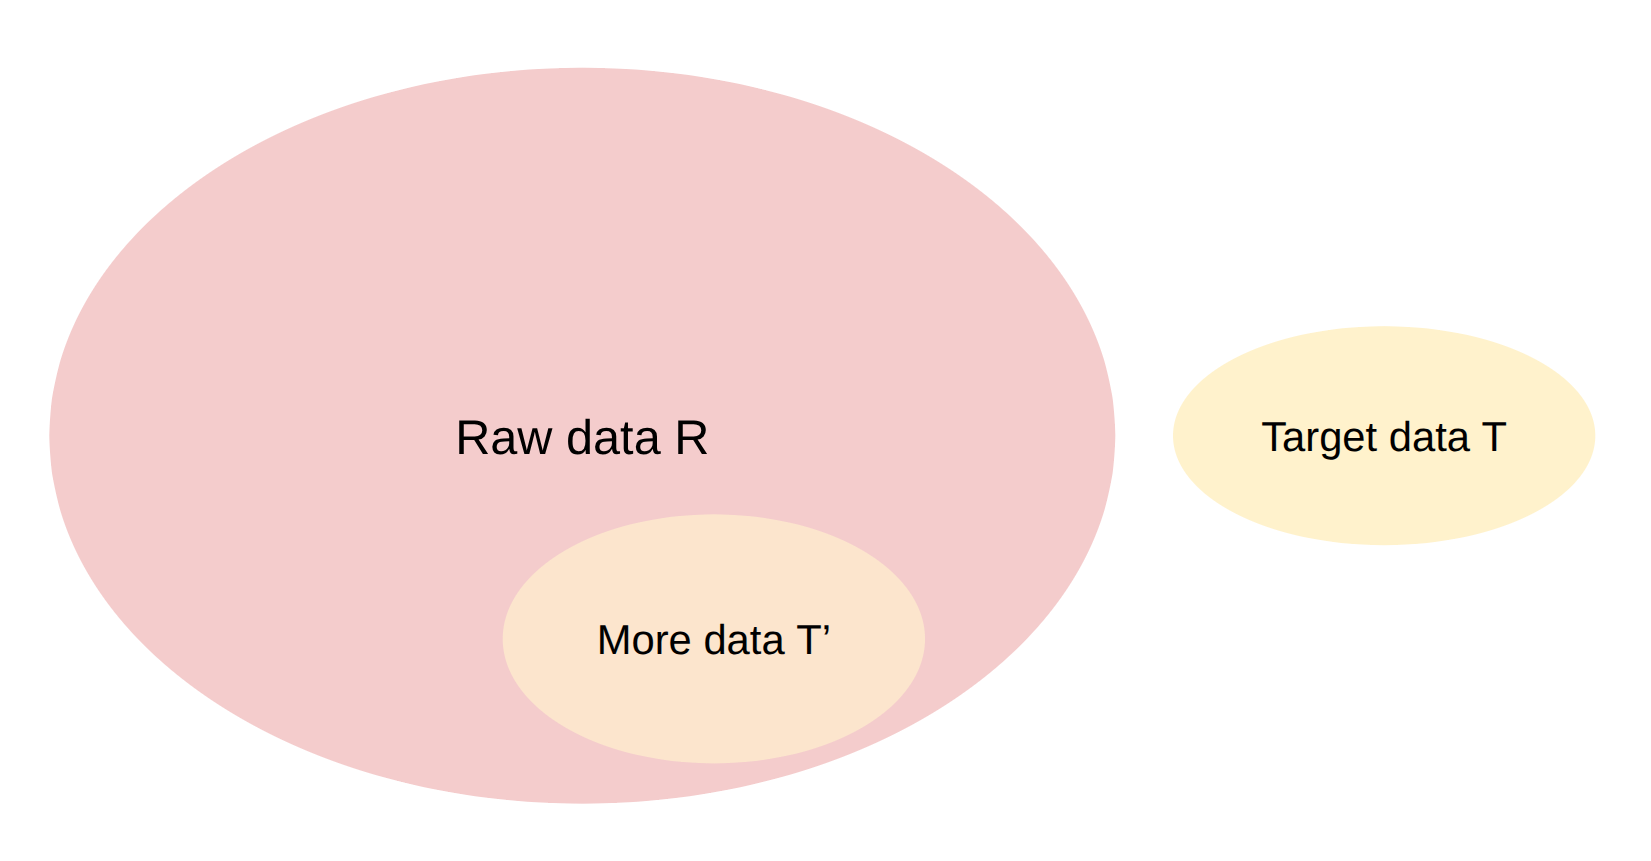
**挑战**：

1.  **泛化能力**：算法需要从有限的 $T$ 中学习，并泛化到巨大的 $R$ 上。
2.  **计算效率**：算法必须极快，因为需要处理的数据量（$R$）非常庞大。

### 1.2 核心过滤算法

这里主要介绍三种用于数据过滤的算法：KenLM、fastText和DSIR。它们代表了不同的建模思想：**生成模型**、**判别模型**和**重要性重采样**。

#### KenLM (Kneser-Ney平滑的N-gram语言模型)

**核心思想**：通过计算文本的\*\*困惑度（Perplexity）\*\*来衡量其质量。困惑度越低，说明文本越符合训练语料的统计分布，质量越高。
KenLM 使用的是一种叫做 **n-gram 语言模型**的算法。它的工作方式很简单：它会学习一门语言的**“正常”模式**。

**工作原理**：
* 它会统计训练语料库中词语出现的概率。比如，它会学到 “the cat” 后面接 “in” 的概率很高，而接 “asdf” 的概率几乎为零。
* 当它处理一个新句子时，它会计算这个句子有多“符合”它所学的模式。
* 这个“不确定性”或“不符合程度”就用**困惑度（Perplexity）**来衡量。困惑度越低，说明句子越符合正常语言模式，质量越高。

**举个例子**：
* 对于句子 “The quick brown fox jumps over the lazy dog.”，KenLM 会发现每个词的组合都很“正常”，它的困惑度会很低。
* 对于句子 “asdf asdf asdf asdf asdf”，KenLM 会发现这些词的组合非常“不正常”，它的困惑度会非常高。

所以，我们可以设定一个困惑度阈值，比如 1000，所有困惑度超过这个值的文本，我们都认为它们是低质量的，直接过滤掉。这种方法简单快速，但有点粗糙，因为它只看词语的局部搭配，不理解句子的深层含义。

它的公式是 $Perplexity(W) = P(w\_1, w\_2, ..., w\_N)^{-1/N}$，其中 $P(w\_1, ..., w\_N)$ 是模型对整个序列的联合概率。由于概率通常非常小，在实际计算中会使用对数概率（Log Probability）。

**应用**：讲义中提到了CCNet（用于LLaMA）的做法，即对文档段落按困惑度排序，然后保留困惑度最低的前1/3，这是一种简单而有效的启发式过滤方法。

```python
import kenlm
import math

def kenlm_main():
    # 讲义中给出的一个KenLM语言模型，用于计算文本的困惑度
    # model_url = "https://huggingface.co/edugp/kenlm/resolve/main/wikipedia/en.arpa.bin"
    # model_path = "var/en.arpa.bin"
    # download_file(model_url, model_path)
    model = kenlm.Model("var/en.arpa.bin") # 假设文件已下载

    def compute(content: str):
        # 对文本进行预处理，添加起始和结束标记，以符合KenLM的输入格式
        content = "<s> " + content.replace(",", " ,").replace(".", " .") + " </s>"

        # 使用KenLM模型计算文本的对数概率（log p(content)）
        score = model.score(content)

        # 获取文本中的token数量，用于标准化
        num_tokens = len(list(model.full_scores(content)))

        # 计算困惑度：exp(-score / num_tokens)，困惑度越低越好
        perplexity = math.exp(-score / num_tokens)
        return score, perplexity

    # 优质文本示例：困惑度较低
    score, perplexity = compute("Stanford University was founded in 1885 by Leland and Jane Stanford as a tribute to the memory of their only child, Leland Stanford Jr.")
    print(f"高质量文本的困惑度: {perplexity}")

    # 低质量文本示例：重复的无意义词语，困惑度很高
    score, perplexity = compute("asdf asdf asdf asdf asdf")
    print(f"低质量文本的困惑度: {perplexity}")

if __name__ == "__main__":
    kenlm_main()
```








### 优化n-gram:**模型架构与参数**

首先，让我们看一下 fastText 的基本架构：

* **Bag of Word Embeddings (词袋嵌入)**: 传统的词袋模型只统计词频，不考虑词语顺序。fastText 更进一步，它将每个词语（word）或词组（n-gram）转换为一个**嵌入向量（embedding vector）**。模型不是使用所有词语，而是将这些向量**取平均值**，得到一个单一的、代表整个文本的向量表示。这就像把一袋子不同形状的珠子（词语）融化成一个大珠子，这个大珠子（平均向量）包含了所有小珠子的大致信息。
* **参数量**：在传统的神经网络中，如果词汇量 $V$ 和类别数 $K$ 都很大，参数矩阵 $W$（$V \times K$）会非常庞大。fastText 引入了一个较小的**隐藏维度 $H$**，将参数分解为两个矩阵：$W$（$V \times H$）和 $U$（$H \times K$）。这样，总参数量从 $V \times K$ 降为 $H \times (V+K)$，大大减少了模型的规模，使其更快。

### **核心问题与解决方案**

讲义中提到的一个关键问题是：**“n-grams的数量可以变得非常大（甚至无界）”**。

* **Bag of n-grams (词组袋)**: fastText 强大之处在于它不仅仅处理单个词语（unigrams），还处理**n-grams**（例如，`the cat`，`cat in`）。这使得模型能捕捉到词语的顺序和局部上下文信息，从而提升性能。然而，可能的 n-grams 组合数量是巨大的，这会使词汇表变得非常大，导致模型难以训练和存储。
* **Solution: Hashing Trick (哈希技巧)**: 为了解决这个问题，fastText 引入了**哈希技巧**。它不是为每个 n-gram 分配一个唯一的 ID，而是将它们通过哈希函数映射到固定数量的**哈希桶（hash bins）**中。
    * 例如，我们将 `the cat` 和 `the hat` 都哈希到同一个哈希桶，那么它们就共享同一个嵌入向量。
    * 这虽然可能导致**哈希冲突（hash collision）**，但由于哈希桶数量足够大（通常有上百万个），这种冲突的概率很低，且对最终模型的性能影响不大。

### **实际应用**

* **质量过滤**：在你的讲义中，fastText 被用于质量过滤，这通常是一个**二元分类（binary classification）**任务，即判断文本是**“好”**还是**“坏”**。在这种情况下，$K=2$。
* **线性分类器**：当隐藏维度 $H$ 等于类别数 $K$ 时，fastText 的模型结构可以简化为一个**线性分类器**，这使得它训练和预测都非常快，是处理大规模数据的理想选择。
* **与其他模型的对比**：讲义最后提到，虽然像 **BERT** 或 **Llama** 这样的大型语言模型也能做分类，但它们的计算量和参数量都远超 fastText。在处理大规模数据过滤这种需要极高效率的场景下，fastText 凭借其**速度**和**简单性**成为更优的选择。


#### fastText (快速文本分类器)
fastText 是一种**监督学习**方法，它需要你提前准备好**高质量**和**低质量**两种样本，然后让它去学习如何区分这两者。

**工作原理**：
* **训练阶段**：你给 fastText 一些“好”的文本（比如维基百科）和一些“坏”的文本（比如论坛垃圾评论），并告诉它哪个是好的，哪个是坏的。
* fastText 会学习这些文本的特征，建立一个分类模型。它的一个核心技巧是**哈希技巧（hashing trick）**，可以高效地处理海量的词语和词组（n-grams），而不需要巨大的词汇表。
* **过滤阶段**：当你把一个新文本给它时，它会根据训练好的模型，给出一个**概率值**。这个概率值表示该文本是“高质量”的概率。

**举个例子**：
* 你可以训练一个 fastText 模型，让它判断一个网页是**英文**还是**中文**。
* 当一个新网页进来时，模型会给出一个概率，比如 `p(English) = 0.95`，我们就可以自信地把它归类为高质量的英文数据。
* 或者，你可以训练一个模型来判断文本是否有**教育价值**。这个模型会给每个代码片段打分，分数高的我们就保留，用于训练高质量的编程模型，比如 phi-1。

fastText 比 KenLM 更灵活和精确，因为它能处理更复杂的过滤任务，比如语言识别、质量判断和毒性过滤。

```python
import numpy as np

def fasttext_main():
    # 快速回顾fastText的参数空间优化思想
    # Baseline：Bag of Words，参数量 V*K
    # fastText：Bag of Word Embeddings，参数量 H*(V+K)，大大减少
    # fastText的精髓在于使用哈希技巧处理n-grams，而不是词汇表


    # 模拟哈希技巧
    training_text = "the cat in the hat"
    ngrams = training_text.split(" ")  # 简单模拟为unigram
    
    num_bins = 8  # 模拟哈希桶的数量
    hashed_ngrams = [hash(ngram) % num_bins for ngram in ngrams]
    print(f"原始n-grams: {ngrams}")
    print(f"哈希后的n-grams（映射到{num_bins}个桶）: {hashed_ngrams}")
    
if __name__ == "__main__":
    fasttext_main()
```
FastText 的模型结构可以理解为一个非常高效、简单的神经网络，主要用于文本分类和词向量学习。

-----

### FastText 的核心思想：平均词嵌入

和传统的深度学习模型（如 BERT）不同，FastText 的设计目标是快。它的核心思想是\*\*“平均词嵌入”（Bag of Word Embeddings）\*\*，这是一种对文本的简单而高效的表示方法。

**它做了三件事来完成文本分类任务：**

1.  **词语嵌入（Word Embeddings）**：为语料库中的每个单词和 n-gram（连续的词组）学习一个向量表示。这个向量能捕捉词语的语义信息。
2.  **文本表示（Text Representation）**：将一个文档中所有词语和 n-gram 的向量**简单地相加或取平均**，得到一个单一的向量，作为整个文档的表示。这种方法不考虑词语的顺序，因此被称为\*\*“词袋”（Bag of Words）\*\*模型。
3.  **线性分类（Linear Classifier）**：将这个文档向量输入到一个简单的线性分类器中，直接预测文本的类别。

-----

### FastText 的模型结构图解

如果你能想象一下，FastText 的模型结构就像一个只有一层的神经网络，从输入到输出的过程非常直接：

  * **输入层 (Input Layer)**：

      * 接收一个文档。这个文档被分解为一系列的单词和 n-gram。
      * 例如，句子 "I love cats" 会被拆解为 `[“I”, “love”, “cats”]`。如果使用 n-gram，它还可能包含 `[“I love”, “love cats”]`。

  * **嵌入层 (Embedding Layer)**：

      * 为输入层中的每个单词和 n-gram 查找对应的**嵌入向量**。这些向量是在训练过程中学习到的。
      * 这就像一个巨大的查找表，输入一个词语，输出一个向量。

  * **隐藏层 (Hidden Layer)**：

      * 这一层是 FastText 最特别的地方。它没有复杂的计算，而是将所有词语和 n-gram 的向量**求和取平均**，得到一个文档的单一向量表示。
      * 这个平均向量包含了文档中所有词语的平均语义信息。

  * **输出层 (Output Layer)**：

      * 接收隐藏层的平均向量，并通过一个**线性变换**和 `Softmax` 函数，预测文档属于每个类别的概率。
      * 例如，对于情感分析，它会给出“正面”和“负面”的概率，你就可以选择概率最高的那个作为最终预测结果。

-----

### 总结 FastText 的优势

FastText 的模型结构之所以简单，是因为它的设计哲学是**牺牲一些精度来换取极高的速度**。这种设计非常适合处理海量数据，比如你讲义中提到的数据过滤任务。

  * **高效**：由于没有复杂的非线性层，FastText 的训练和推理速度比 BERT 等复杂模型快得多。
  * **轻量**：参数量小，占用内存少，易于部署。
  * **善于处理未登录词（OOV）**：由于它使用 n-gram 级别的信息（比如词语的子词），即使遇到一个训练时未见过的词，它也能根据其组成部分来构建一个合理的向量，这对于处理拼写错误或新词非常有用。

### DSIR (Data Selection via Importance Resampling)
DSIR 的思想更高级，它不是简单地“筛选”文本，而是**“重塑”**文本的分布。它不丢弃任何数据，而是为每个数据分配一个**权重**。
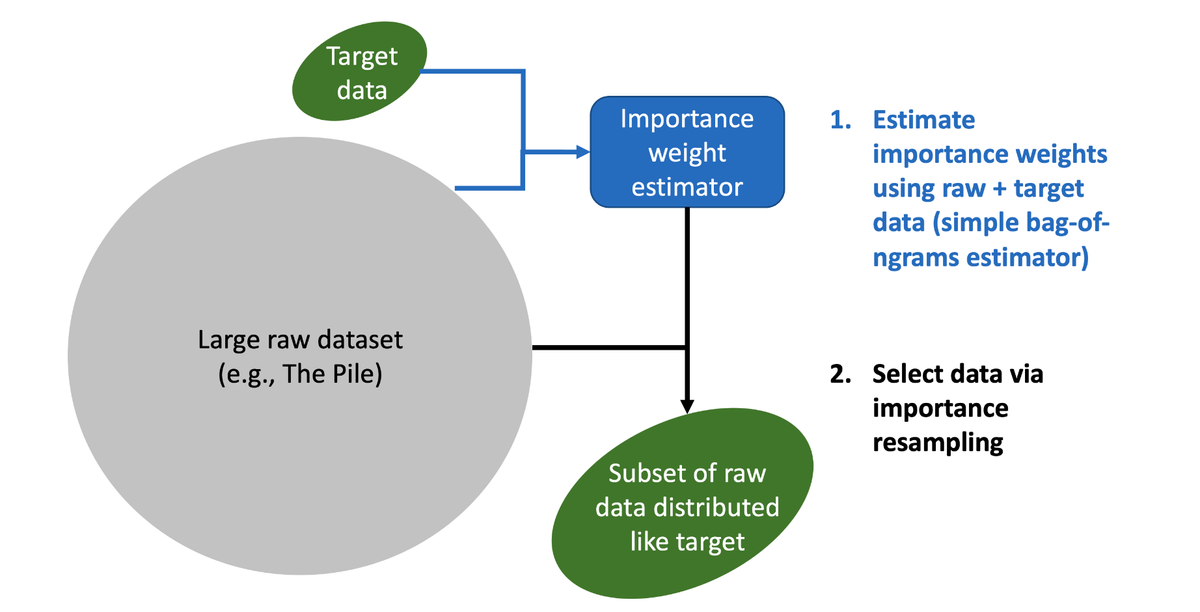
**工作原理**：
* 它有两个分布：一个是你拥有的**海量低质量数据分布 $q$**，一个是你想要的**高质量数据分布 $p$**。
* 它会计算一个**权重** $w = p/q$。这个权重反映了每个数据点在高质量数据中出现的频率相对于它在低质量数据中出现的频率。
* **重采样**：它会根据这个权重对原始数据进行**重新采样**。权重越高的数据，被采样的概率就越大。

**举个例子**：
假设你的原始数据中，“Python”这个词出现了1000次，而“Java”只出现了10次。但你希望模型更偏向“Java”，因为这是你的目标领域。
DSIR 会计算出“Java”的权重比“Python”高得多，这样在重采样时，“Java”相关的数据就会被多次选中，而“Python”相关的数据被选中的次数会相对减少。

最终，你得到一个**新数据集**，它的内容构成和分布更接近你设想的高质量数据，而不是简单地丢弃了大量数据。这种方法比前两者更“科学”和“原则性”。

**核心思想**：DSIR 将数据过滤视为一个**重要性重采样（Importance Resampling）问题。它不像 KenLM 那样直接筛选，也不像 fastText 那样做分类，而是通过计算一个重要性权重** $w(x) = p(x) / q(x)$ 来重新对数据进行抽样。

  * $p(x)$：高质量目标数据分布的概率。
  * $q(x)$：原始大规模数据分布的概率。

DSIR 使用哈希 N-gram 来近似估计 $p(x)$ 和 $q(x)$，然后根据计算出的权重 $w(x)$ 对原始数据进行重采样，从而得到一个在分布上更接近目标数据的新数据集。

```python
import numpy as np

def dsir_main():
    # 简单模拟重要性重采样的过程
    vocabulary = [0, 1, 2, 3]
    p = [0.1, 0.2, 0.3, 0.4]  # 目标分布 (target distribution)
    q = [0.4, 0.3, 0.2, 0.1]  # 原始分布 (proposal distribution)

    # 1. 从原始分布 q 中进行采样
    n = 100
    samples_from_q = np.random.choice(vocabulary, p=q, size=n)
    
    # 2. 计算每个样本的重要性权重 w = p/q


    weights = np.array([p[x] / q[x] for x in samples_from_q])
    
    # 3. 对权重进行归一化，得到新的采样概率
    normalized_weights = weights / np.sum(weights)
    
    # 4. 根据新的概率对原始样本进行重采样
    resampled_samples = np.random.choice(samples_from_q, p=normalized_weights, size=n)

    print("原始分布q的样本（前10个）: ", samples_from_q[:10])
    print("重采样后更接近目标分布p的样本（前10个）: ", resampled_samples[:10])

if __name__ == "__main__":
    dsir_main()
```
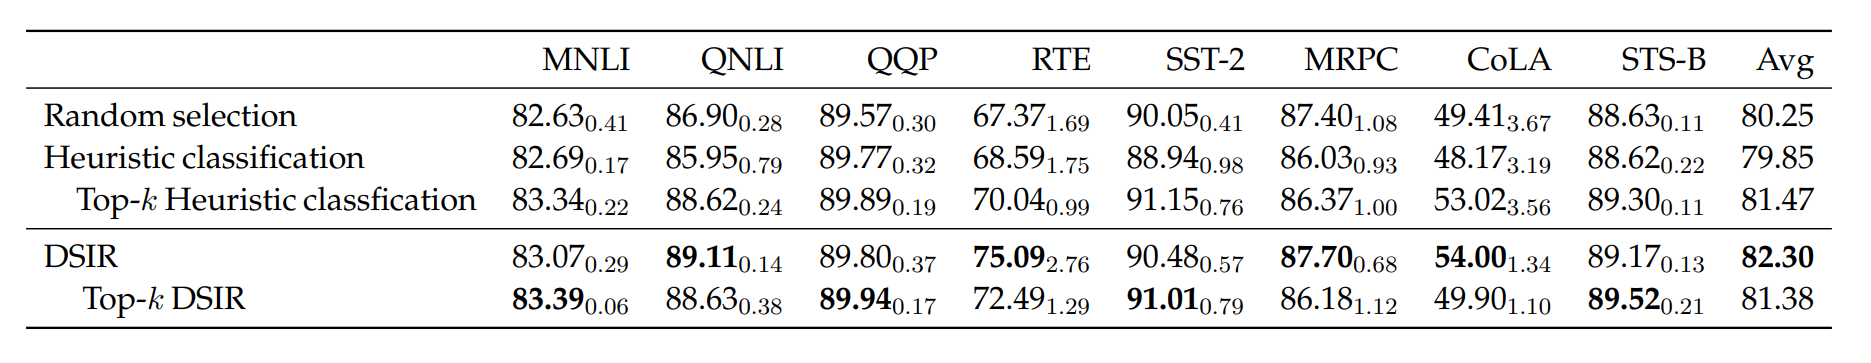
好的，我们用一个具体的例子来解释 DSIR（Data Selection for Language Models via Importance Resampling）的重要性重采样，这样会更容易理解。

假设你是一个 AI 工程师，需要训练一个**针对法律领域**的语言模型。

### **场景设置**

* **你的原始数据（Raw data）D_q**：你从互联网上爬取了 10TB 的文本，这是一个巨大的、包含各种内容的“大杂烩”。里面有新闻、博客、论坛帖子，当然也夹杂着一些法律文件。
* **你的目标数据（Target data）D_p**：你手动收集了 10GB 的高质量法律文书，比如法律条文、判决书等。这些数据量很小，但质量极高，代表了你希望模型学习的“专业”领域。

你的问题是：如何利用这 10TB 的大杂烩，使其在**分布上**更接近那 10GB 的专业法律文本？

直接从 10TB 中随机采样 10GB 肯定不行，因为你可能会采样到大量无用的八卦新闻或食谱。你希望更多地采样到那些“看起来像法律文本”的数据。

这就是 DSIR 的用武之地。

---

### **DSIR 的核心步骤**

DSIR 不会简单地扔掉数据，而是通过“重新分配抽样机会”来解决问题。

**步骤 1：建模两个分布**

首先，DSIR 会为你的两种数据分别建立一个**模型**来描述它们的分布。这两个模型都很简单，可以基于哈希 n-gram 来构建，这能快速统计词组出现的频率：

* **原始分布 q(x)**：表示任何一个文本 $x$ 在你 10TB 大杂烩中出现的概率。这个模型会告诉你，新闻、博客和普通对话出现的概率都很高。
* **目标分布 p(x)**：表示任何一个文本 $x$ 在你 10GB 法律文档中出现的概率。这个模型会告诉你，“判决”、“原告”、“被告”等词语出现的概率非常高。

**步骤 2：计算重要性权重**

对于 10TB 原始数据中的每一份文档 $x$，DSIR 都会计算一个**重要性权重** $w(x)$：

$w(x) = \frac{p(x)}{q(x)}$

这个权重 $w(x)$ 是 DSIR 最核心的概念。它代表了**“这份文档在目标领域中的重要性是它在原始数据中重要性的多少倍”**。

* 对于一份普通的**八卦新闻**文档：$p(x)$（在法律文档中出现的概率）几乎为 0，而 $q(x)$（在互联网上出现的概率）很高。所以，$w(x)$ 会非常小，接近 0。
* 对于一份**法律文件**文档：$p(x)$（在法律文档中出现的概率）很高，而 $q(x)$（在互联网上出现的概率）相对较低。所以，$w(x)$ 会非常大。

**步骤 3：重要性重采样**

最后，DSIR 根据计算出的权重 $w(x)$ 对 10TB 的原始数据进行**重新抽样**。

* $w(x)$ 很小的八卦新闻，被抽中的概率也相应地变得很低，基本会被忽略。
* $w(x)$ 很大的法律文件，被抽中的概率会大大提高，甚至会被重复抽样多次。

最终，你将得到一个**新数据集**，它的大小可以设定（比如 100GB），但它的**数据分布**和**词语构成**会更接近你那 10GB 的高质量法律文档，而不是原始的 10TB 杂乱数据。




### 1.3 过滤应用

这三种算法构成的框架可以被用于多种具体的过滤任务。

#### 语言识别（Language Identification）

这是一个经典的文本分类任务，通常使用 fastText 训练一个多语言分类器。Dolma 数据集就是通过 fastText 筛选出英语文档。需要注意的是，这种方法对于短文本、低资源语言、方言和语码混合（code-switching）等情况可能效果不佳。

```python
import fasttext

def language_identification():
    # 下载用于语言识别的fastText模型
    # model_url = "https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin"
    # model_path = "var/lid.176.bin"
    # download_file(model_url, model_path)
    model = fasttext.load_model("var/lid.176.bin") # 假设文件已下载

    # 预测不同语言和类型的文本
    predictions = model.predict(["The quick brown fox jumps over the lazy dog."]) # 英语
    print(f"英语文本预测结果: {predictions}")
    
    predictions = model.predict(["Auf dem Wasser zu singen"]) # 德语
    print(f"德语文本预测结果: {predictions}")

    predictions = model.predict(["for (int i = 0; i < 10; i++)"]) # C++代码，可能被误判为某种语言
    print(f"C++代码预测结果: {predictions}")

if __name__ == "__main__":
    language_identification()
```

#### 质量过滤（Quality Filtering）

通过训练一个分类器，将高质量文本（如维基百科、书籍）和低质量文本（如通用爬虫数据）区分开。GPT-3、LLaMA 和 phi-1 都使用了类似的策略。

讲义中提到的 **phi-1** 模型是一个很好的例子，它强调**高质量**数据的重要性。他们使用 GPT-4 对 The Stack（一个代码数据集）进行标注，然后用这个小规模的高质量数据集训练一个分类器，再用该分类器从大规模原始数据中筛选出高质量的代码。结果表明，这种\*\*“小而精”\*\*的数据集训练出的模型，在性能上甚至超过了使用20倍原始数据训练的模型。

这在 AI 应用开发中是一个重要的启示：**“数据比模型架构更重要”**。与其盲目地收集海量数据，不如花更多精力清洗和筛选出高质量、有教育价值的数据。

#### 毒性过滤（Toxicity Filtering）

与质量过滤类似，通过训练分类器来识别和过滤掉有害、冒犯或不安全的内容。讲义以 Dolma 数据集为例，介绍了如何使用 fastText 训练一个毒性分类器。

-----


## 2\. 数据去重（Deduplication）

### 2.1 去重的必要性

大型数据集中存在大量的重复和近乎重复的内容，例如镜像站点、GitHub 仓库的 fork、重复的法律条款（如 MIT 许可证）等。

**为什么需要去重？**

1.  **提高训练效率**：减少训练 tokens 的数量，模型可以更快地收敛。
2.  **避免模型记忆（Memorization）**：防止模型过度记忆重复内容，从而减少版权和隐私泄露的风险，并提高模型的泛化能力。

### 2.2 精确去重（Exact Deduplication）

**核心思想**：通过哈希（Hash）来快速识别完全相同的文档或文本块。这是一种精确的匹配方法，可以通过 MapReduce 等分布式框架高效实现。

**缺点**：无法处理“近乎重复”（Near duplicates）的情况，例如只改变了几个单词或格式的文本。


### 2.3 近似去重（Near-Duplicate Deduplication）

#### Bloom Filter

**核心思想**：一个用于高效测试集合成员资格的概率性数据结构。它能以极低的内存占用判断一个元素**可能存在**或**绝对不存在**于集合中。

**工作原理**：

1.  初始化一个全为0的位数组（bitarray）。
2.  对于要插入的每个元素，使用**k个独立的哈希函数**计算出 k 个位置。
3.  将这 k 个位置的位都设为1。
4.  查询时，同样计算 k 个位置，如果所有位置都为1，则判断元素**可能存在**。

**特性**：

  * **高效**：空间和时间复杂度都很低。
  * **概率性**：存在**假阳性（false positive）**，即“可能存在”但实际上不存在。但**绝无假阴性（false negative）**，即“绝对不存在”就是不存在。
  * 假阳性率可以通过增加位数组大小（m）和调整哈希函数数量（k）来降低。讲义中给出了优化 `k` 值的公式 `k = math.log(2) * m / n`，这在工程实践中非常有价值。

<!-- end list -->

```python
import mmh3
from bitarray import bitarray

def bloom_filter():
    items = ["the", "cat", "in", "the", "hat"]
    non_items = ["what", "who", "why", "when", "where", "which", "how"]
    
    m = 1000 # 位数组大小
    k = 10   # 哈希函数数量
    
    # 构建Bloom Filter
    def build_table_k(items: list[str], num_bins: int, k: int):
        table = bitarray(num_bins)
        table.setall(0)
        for item in items:


            for seed in range(k):
                h = mmh3.hash(item, seed) % num_bins
                table[h] = 1
        return table

    table = build_table_k(items, m, k)
    
    # 查询非成员元素，查看假阳性率
    def query_table_k(table: bitarray, item: str, num_bins: int, k: int):
        return int(all(
            table[mmh3.hash(item, seed) % num_bins] for seed in range(k)
        ))

    result = {item: query_table_k(table, item, m, k) for item in non_items}
    num_mistakes = sum(result.values())
    false_positive_rate = num_mistakes / len(non_items)

    print(f"查询非成员元素结果: {result}")
    print(f"假阳性（误判）数量: {num_mistakes}")
    print(f"假阳性率: {false_positive_rate:.4f}")

if __name__ == "__main__":
    bloom_filter()
```


#### Jaccard MinHash & Locality Sensitive Hashing (LSH)

这是处理近似去重的另一套经典算法。

**Jaccard 相似度**：衡量两个集合相似度的指标，定义为 $|A \\cap B| / |A \\cup B|$。对于文档，我们可以将其转换为**shingles**（连续的N个字符或词组成的集合）来计算相似度。

**MinHash**：一种哈希技术，其核心思想是 $Pr[minhash(A) == minhash(B)] = Jaccard(A, B)$。通过多次计算 MinHash，我们可以得到两个文档相似度的近似估计，但单独的 MinHash 很难用于大规模去重。

**LSH（局部敏感哈希）**：LSH 是一个通用的概念，它指的是一类哈希函数，这些函数能够将“相似”的输入哈希到同一个“桶”中，而“不相似”的输入则很少会发生碰撞。

**如何结合 MinHash 和 LSH 进行去重？**

1.  **分块（Shingling）**：将每个文档分解为小的子项（如 N-grams）。
2.  **MinHash 签名**：对每个文档生成一个由多个 MinHash 值组成的签名（Signature）。
3.  **分带（Banding）**：将签名向量分成 `b` 个小波段（band），每个波段有 `r` 个哈希值。
4.  **哈希桶**：对每个波段，将其作为一个整体进行哈希，将文档放入相应的哈希桶中。
5.  **碰撞检测**：如果两个文档在**任意一个**波段中发生了哈希碰撞，则它们被认为是“近乎重复”的候选对。

这种\*\*“AND-OR”**结构极大地**锐化了相似度曲线\*\*。当 Jaccard 相似度高于某个阈值时，它们发生碰撞的概率会急剧增加，从而实现高效的近似去重。

```python
import numpy as np

def locality_sensitive_hashing():
    # 模拟LSH的锐化效应
    def get_prob_collision(sim, b, r):
        # 概率：某个固定波段匹配的概率
        prob_match = sim ** r
        # 概率：至少一个波段匹配的概率
        prob_collision = 1 - (1 - prob_match) ** b
        return prob_collision

    sims = np.arange(0.5, 1.01, 0.05)

    
    # 实验不同的b和r组合
    b, r = 10, 10  # 一个组合
    probs1 = [get_prob_collision(sim, b, r) for sim in sims]
    print(f"b={b}, r={r}时的碰撞概率: {probs1}")
    
    b, r = 10, 20  # 增加 r，曲线更陡峭，阈值右移（更难碰撞）
    probs2 = [get_prob_collision(sim, b, r) for sim in sims]
    print(f"b={b}, r={r}时的碰撞概率: {probs2}")

    b, r = 20, 10  # 增加 b，曲线更平缓，阈值左移（更容易碰撞）
    probs3 = [get_prob_collision(sim, b, r) for sim in sims]
    print(f"b={b}, r={r}时的碰撞概率: {probs3}")

if __name__ == "__main__":
    locality_sensitive_hashing()
```

-----
Jaccard MinHash 和 LSH（局部敏感哈希）确实是数据去重中最难理解的部分，因为它们涉及概率和近似算法。我们可以用一个更具体的、非技术的比喻来解释它们，然后回到技术细节。

---

### **大白话比喻：寻找相似的朋友**

假设你在一个巨大的社交网络中（原始数据），你想找到与你的**兴趣爱好**（文档内容）非常相似的朋友。

* **你的兴趣列表 A**：`{电影, 篮球, 烹饪, 旅行}`
* **朋友的兴趣列表 B**：`{电影, 篮球, 烹饪, 跑步}`

**1. Jaccard 相似度：衡量相似度**

Jaccard 相似度就是用来量化你和朋友之间有多相似。它计算的是**共同兴趣的数量**除以**所有兴趣的总数**。

* 共同兴趣（交集）：`{电影, 篮球, 烹饪}`，数量为 3。
* 所有兴趣（并集）：`{电影, 篮球, 烹饪, 旅行, 跑步}`，数量为 5。
* **Jaccard 相似度** = 3 / 5 = 0.6。

你的目标是：找到 Jaccard 相似度高于某个阈值（比如 0.8）的朋友。但这个网络太大了，你不可能和每个人都做一次对比。

**2. MinHash：用“最小哈希”代替整个列表**

为了高效地寻找，MinHash 提供了一个巧妙的解决方案：我们不比较完整的兴趣列表，而是比较每个列表的**“代表兴趣”**。

* 想象你和朋友都用一种随机的方法，把自己的兴趣列表**打乱顺序**。
* **MinHash** 就是找到打乱后**排名最靠前**的那个兴趣。
* 如果你和朋友的兴趣列表非常相似，那么在多次随机打乱后，你们找到的“排名最靠前的兴趣”很可能是同一个。

这个过程的神奇之处在于：**两个兴趣列表的 MinHash 结果相同的概率，正好等于它们的 Jaccard 相似度。**
* 如果你的兴趣列表和朋友的列表 80% 相似，那么你们的 MinHash 结果有 80% 的概率会一样。

所以，我们只需要比较 MinHash 的结果，就可以近似估算出 Jaccard 相似度。
好的，我们把 LSH (Locality Sensitive Hashing) 再详细地讲一遍。我会用一个更简单的类比，然后直接切入它的工作原理，确保这次你能完全理解。

---

### LSH 的核心思想

LSH 的核心思想是：**“如果两个东西很相似，它们被分到同一个桶里的概率就很高；如果它们不相似，被分到同一个桶里的概率就很低。”**

这听起来很像一个完美的哈希函数，但我们知道完美的哈希函数是不存在的。LSH 的天才之处在于，它通过一个巧妙的**“分带（banding）”**策略，来**放大**这种概率差异，将原本平滑的相似度曲线，变成一条陡峭的“S”形曲线。

---

### 用“密码锁”来比喻 LSH

想象一下，每篇文档都有一个由 12 个数字组成的“密码”（这个密码就是文档的 MinHash 签名）。

* **文档 A 的密码：** `[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]`
* **文档 B 的密码：** `[1, 2, 3, 4, 15, 6, 7, 8, 9, 10, 11, 12]`
* **文档 C 的密码：** `[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32]`

从密码本身看，A 和 B 只有 1 个数字不同，C 则和 A、B 截然不同。你想要一个快速的方法，在不逐个比较密码的情况下，找出 A 和 B 这样“很相似”的文档。

**LSH 的步骤：**

**1. 分带 (Banding)**

你把这个 12 位密码分成 3 个**波段（Bands）**，每个波段 4 个数字。

* **文档 A 的波段：**
    * 波段 1: `[1, 2, 3, 4]`
    * 波段 2: `[5, 6, 7, 8]`
    * 波段 3: `[9, 10, 11, 12]`

* **文档 B 的波段：**
    * 波段 1: `[1, 2, 3, 4]`
    * 波段 2: `[15, 6, 7, 8]`
    * 波段 3: `[9, 10, 11, 12]`

* **文档 C 的波段：**
    * 波段 1: `[21, 22, 23, 24]`
    * 波段 2: `[25, 26, 27, 28]`
    * 波段 3: `[29, 30, 31, 32]`

**2. 哈希桶 (Buckets)**

现在，你为每个波段设置一个**哈希桶**。你对**每个波段**进行哈希（将波段内的所有数字作为一个整体），然后将文档放入对应的哈希桶中。

* **文档 A**
    * 波段 1 的哈希值 → 桶 `H1`
    * 波段 2 的哈希值 → 桶 `H2`
    * 波段 3 的哈希值 → 桶 `H3`
* **文档 B**
    * 波段 1 的哈希值 → **桶 `H1`**
    * 波段 2 的哈希值 → 桶 `H4` (因为 `[15, 6, 7, 8]` 是新的)
    * 波段 3 的哈希值 → **桶 `H3`**

你会发现，文档 A 和 B 在波段 1 和波段 3 的哈希值完全相同，所以它们都被分到了 `H1` 和 `H3` 这两个桶里。

**3. 找到候选对 (Candidate Pairs)**

LSH 的规则很简单：**如果两个文档在至少一个哈希桶中发生碰撞，它们就是潜在的重复文档。**

通过这个方法，你不需要比较全部的 12 个数字，只需要看看它们有没有在任何一个波段上完全匹配。

* 在我们的例子中，A 和 B 在波段 1 和 3 都匹配了，所以它们被标记为“潜在重复”。
* C 的密码和 A、B 完全不同，它不可能和 A 或 B 匹配任何一个波段，所以它们不会被分到同一个桶里。

---

### LSH 的“S”形曲线

这个“分带”策略的巧妙之处在于它如何改变相似度-碰撞概率的曲线。

* **低相似度**：如果两篇文档相似度很低（比如 0.2），它们 12 个数字都相同的概率本来就很低。分成 3 个波段后，它们在**某个波段**内所有 4 个数字都完全相同的概率会变得**极低**。
* **高相似度**：如果两篇文档相似度很高（比如 0.9），它们 12 个数字中有 9 个相同的概率很高。分成 3 个波段后，它们至少有**一个波段**内所有 4 个数字都完全相同的概率会变得**非常高**，几乎是 100%。

LSH 就是通过这种**“AND-OR”**的逻辑，将一个平缓的概率变化（MinHash）转换为一个戏剧性的“S”形变化。这个陡峭的曲线使得 LSH 能够非常高效地识别出高相似度的文档，同时过滤掉绝大多数不相似的文档，从而将大规模的去重问题转化为一个简单的哈希查找问题。

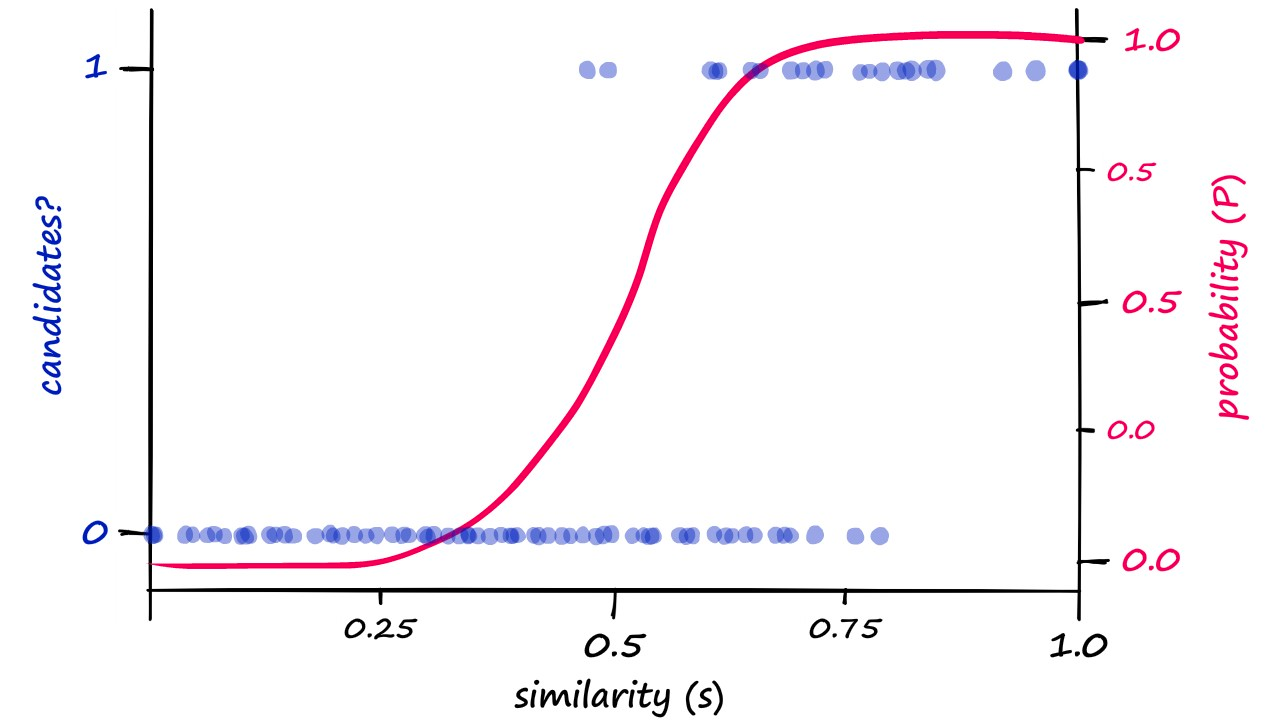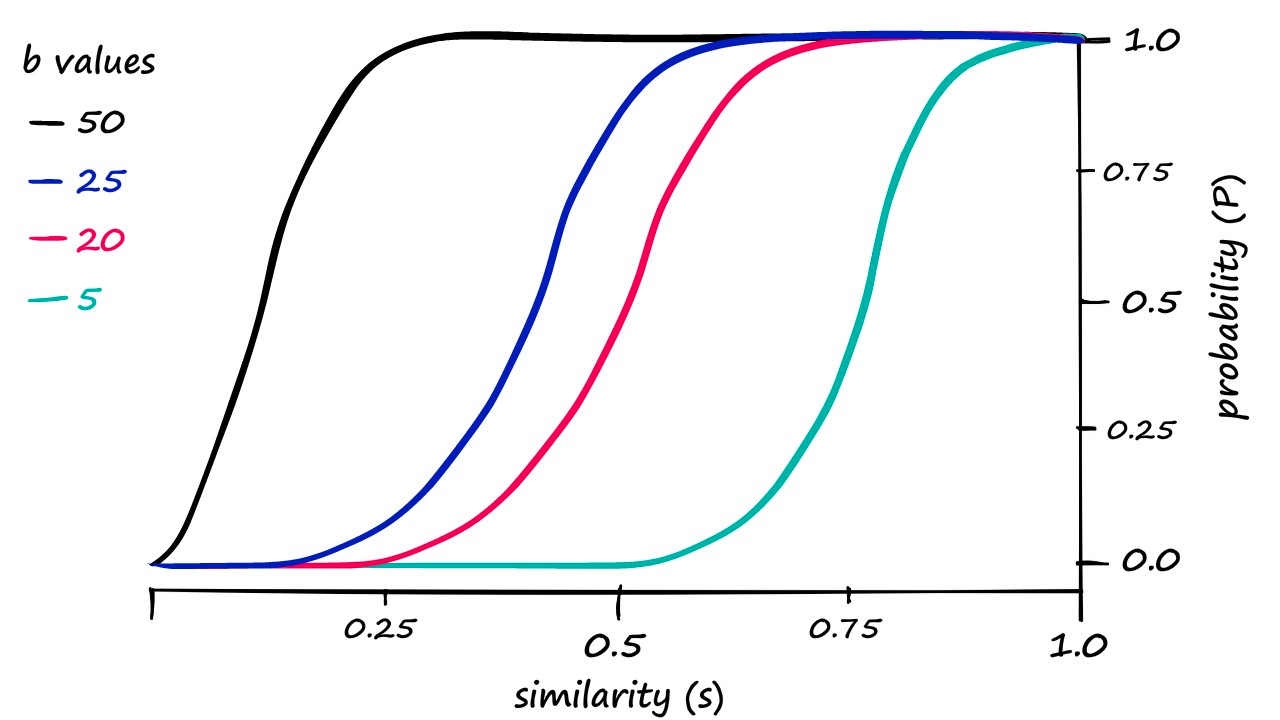
好的，这两张图片很直观地解释了 LSH（局部敏感哈希）的关键概念。我来为你详细解读一下。

---

### 第一张图：LSH 如何将相似度转化为候选概率

第一张图展示了 **LSH 的基本工作原理**，以及它如何将**文档相似度（s）**转化为**碰撞概率（P）**。

* **x 轴（similarity s）**：代表两篇文档的 Jaccard 相似度，从 0（完全不相似）到 1.0（完全相同）。
* **y 轴（candidates? / probability P）**：有两个 Y 轴，左边是 `candidates?`（候选对？），右边是 `probability P`（概率 P）。
    * `candidates?`：图中的蓝色小点，代表实际的文档对。点在 1 的位置表示 LSH 算法认为它们是**潜在的重复文档**；点在 0 的位置表示 LSH 认为它们**不重复**。
    * `probability P`：图中的红色 S 形曲线，代表理论上，文档对因为 LSH 而发生碰撞的概率。

**核心思想**：

这张图最重要的地方在于这条**红色 S 形曲线**。它告诉我们，LSH 算法并不是一个简单的线性关系，而是一个**“阶段性变化”**。

* 当文档的相似度 **s 很低**时（例如小于 0.4），碰撞概率 **P 几乎为 0**。这意味着 LSH 算法会非常有效地将这些不相似的文档过滤掉，几乎不会将它们标记为候选对。
* 当文档的相似度 **s 达到某个阈值**后（例如 0.5），碰撞概率 **P 会迅速飙升**。这意味着相似度一旦跨过这个门槛，文档对被 LSH 算法标记为候选对的概率就会急剧增加。
* 当文档的相似度 **s 很高**时（例如大于 0.75），碰撞概率 **P 几乎为 1.0**。LSH 会以极高的概率找到这些文档，并将它们分到同一个哈希桶里。

这张图清晰地表明，LSH **“放大了”**相似度之间的差异。它能将大量的、不相似的文档对迅速剔除，而只保留那些真正有潜在相似性的文档对，大大提高了去重效率。

---

### 第二张图：LSH 参数对阈值的影响

第二张图进一步展示了 LSH 的两个关键参数 **`b`（bands, 波段数）** 和 **`r`（rows, 每波段行数）** 如何影响那条 S 形曲线的形状和位置。

* **x 轴（similarity s）**：与第一张图相同，代表文档相似度。
* **y 轴（probability P）**：代表碰撞概率。
* **不同颜色曲线**：代表不同的 `b` 值（波段数）。这张图假设 `r` 值是固定的，并通过改变 `b` 的值，来观察曲线的变化。

**核心思想**：

LSH 的 S 形曲线由公式 $1 - (1 - s^r)^b$ 决定。这张图通过改变 `b` 的值，形象地说明了这一点：

* **增加 `b` 值**（例如从 5 增加到 50），曲线会向**左移动并变得更陡峭**。
    * **向左移动**：这意味着算法对相似度要求更低了，即使文档相似度只有 0.25，它们被标记为候选对的概率也变得很高。换句话说，增加 `b` 会让 LSH 变得**更宽容**，能找到更多“轻微相似”的文档对。
    * **更陡峭**：斜率变大，代表阈值更加尖锐。一旦相似度超过阈值，碰撞概率会更快地从 0 飙升到 1。

**为什么会这样？**

* `b` 越大，意味着签名被分成的波段越多。
* 由于 LSH 只要**任意一个波段**匹配就会发生碰撞，所以波段越多，发生碰撞的机会就越大。
* 因此，即使文档相似度不高，它们也更有可能在某个波段上意外匹配，从而被 LSH 捕捉到。

你可以把 `b` 理解为 LSH 的**“灵敏度”**。通过调整 `b` 和 `r` 的值，你可以根据具体需求（比如是需要找到严格相似的文档，还是稍微有点相似的文档）来控制去重算法的灵敏度。这正是 LSH 在大规模数据处理中如此灵活和强大的原因。



## 3\. 总结

本讲义深入剖析了LLM数据预处理的两大基石：**过滤和去重**。

  * **过滤**：使用 KenLM（生成模型）、fastText（判别模型）和 DSIR（重要性重采样）等算法，根据语言、质量和毒性等标准来筛选数据。
  * **去重**：使用哈希（精确去重）以及 Bloom Filter、MinHash 和 LSH 等算法（近似去重），从大规模数据集中移除重复或相似的内容。
